In [1]:
import os
# Setează numărul de nuclee dorit (ex: 16)
n_core = "16"
os.environ["OMP_NUM_THREADS"] = n_core
os.environ["MKL_NUM_THREADS"] = n_core
os.environ["OPENBLAS_NUM_THREADS"] = n_core
os.environ["VECLIB_MAXIMUM_THREADS"] = n_core
os.environ["NUMEXPR_NUM_THREADS"] = n_core

import numpy as np
import warnings
# suppress warnings
warnings.filterwarnings('ignore')



import pandas as pd
import matplotlib.pyplot as plt


# Fundamentul Matematic al Algoritmului PerfectPCA

Acest document explică riguros aparatul matematic din spatele clasei `PerfectPCA`. Algoritmul folosește concepte fundamentale din statistică și algebra liniară pentru a roti și proiecta un set de date multidimensional pe axe ortogonale (perpendiculare) de varianță maximă.

---

### 1. Centrarea și Standardizarea Datelor
Fie $X$ matricea datelor de dimensiune $n \times p$ ($n$ eșantioane, $p$ caracteristici). Pentru a asigura o analiză corectă, datele trebuie normalizate.

Calculăm media ($\mu_j$) și deviația standard ($\sigma_j$) pentru fiecare caracteristică (coloană) $j$:
$$\mu_j = \frac{1}{n} \sum_{i=1}^{n} X_{ij}, \quad \sigma_j = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (X_{ij} - \mu_j)^2}$$

Transformarea fiecărui element se face prin scăderea mediei și împărțirea la deviația standard (Z-score normalization):
$$X_{scaled} = \frac{X - \mu}{\sigma}$$

* **Efect geometric:** Centrarea mută originea sistemului de coordonate în centrul norului de puncte. Scalarea rescrie unitățile de măsură, astfel încât toate caracteristicile să aibă varianța egală cu $1$, împiedicând variabilele cu valori mari să domine algoritmul.

---

### 2. Matricea de Covarianță cu Corecția Sample ($\Sigma$)
Covarianța măsoară gradul de corelație liniară dintre două variabile. 
Pentru a măsura dependențele liniare dintre variabile, calculăm matricea de covarianță $\Sigma$ de dimensiune $p \times p$. Deoarece lucrăm cu un eșantion de date (sample), folosim corecția Bessel impunând numitorul $n-1$:
$$\Sigma = \frac{1}{n-1} X_{scaled}^T X_{scaled}$$

* Corecția lui Bessel este ajustarea matematică prin care se împarte la n - 1 în loc de n la calcularea varianței unui eșantion, adică mărirea artificială și controlată a rezultatului final.
* Pe diagonala principală obținem varianțele fiecărei variabile (care vor fi egale cu $1$ datorită pasului de standardizare).
* În afara diagonalei, elementul $\Sigma_{ij}$ reprezintă covarianța dintre caracteristica $i$ și caracteristica $j$.
* Matricea $\Sigma$ este **simetrică** ($\Sigma = \Sigma^T$), o proprietate critică pentru pasul următor.
##### Markov VS Covariație
* În lanțul Markov, harta îți arată cum se transmite probabilitatea de la o stare la alta.
* În matricea de covarianță, harta îți arată cum se transmite variația (informația) de la o caracteristică la alta.

---

### 3. Problema de Optimizare și Multiplicatorii lui Lagrange
Scopul PCA este găsirea unui vector unitar de proiecție $w$ (unde $\|w\|^2 = w^T w = 1$) de-a lungul căruia varianța datelor proiectate să fie maximă.
Varianța datelor proiectate $X_{scaled}w$ este descrisă de forma pătratică:
$$\text{Var}(X_{scaled}w) = w^T \Sigma w$$

* suma pătratelor componentelor sale $\|w\|^2 = w_1^2 + w_2^2, ...$ produsul scalar dintre vectorul w transpus și el însuși


Pentru a maximiza această valoare sub constrângerea $w^T w = 1$, construim funcția **Lagrangiană**:
$$\mathcal{L}(w, \lambda) = w^T \Sigma w - \lambda (w^T w - 1)$$

* Funcția Lagrangiană (sau pe scurt, Lagrangianul) este un truc matematic genial folosit pentru a rezolva probleme de optimizare (găsirea unui maxim sau a unui minim) atunci când ai constrângeri. Formula generală a unei funcții Lagrangiene $$\mathcal{L}(x, \lambda) = f(x) - \lambda \cdot g(x)$$. unde : 
* $\mathcal{L}(x, \lambda)$ este **Lagrangianul** (noua funcție extinsă).
* $f(x)$ este **Funcția Obiectiv** (ceea ce dorești să maximizezi sau să minimizezi).
* $g(x) = 0$ este **Constrângerea** (restricția geometrică, scrisă obligatoriu astfel încât să fie egală cu zero).
* $\lambda$ (Lambda) este **Multiplicatorul lui Lagrange** (un scalar ce determină intensitatea penalizării).

Calculând gradientul în raport cu $w$ și egalându-l cu vectorul nul pentru a găsi punctele critice, obținem:
$$\frac{\partial \mathcal{L}}{\partial w} = 2\Sigma w - 2\lambda w = 0 \implies \Sigma w = \lambda w$$

#### Deducție
$$\mathcal{L}(w, \lambda) = w^T \Sigma w - \lambda (w^T w - 1)$$
$$\mathcal{L}(w, \lambda) = w^T \Sigma w - \lambda w^T w + \lambda$$

Pentru a deriva în raport cu un vector $w$, aplicăm două reguli fundamentale din calculul diferențial matricial:
1. **Regula Formei Pătratice:** Dacă o matrice $A$ este simetrică, atunci:
   $$\frac{\partial}{\partial w}(w^T A w) = 2Aw$$
2. **Derivata unei Constante:** Dacă un termen nu depinde de vectorul $w$, derivata sa în raport cu $w$ este nulă:
   $$\frac{\partial}{\partial w}(\text{Constantă}) = 0$$
  


##### Calcularea Gradientului pentru Fiecare Termen
Aplicăm operatorul de derivare parțială $\frac{\partial}{\partial w}$ asupra fiecăruia dintre cei trei termeni ai Lagrangianului:

* **Primul termen ($w^T \Sigma w$):** Deoarece matricea de covarianță $\Sigma$ este prin definiție simetrică, aplicăm direct Regula Formei Pătratice (unde $A = \Sigma$):
  $$\frac{\partial}{\partial w} (w^T \Sigma w) = 2\Sigma w$$

* **Al doilea termen ($\lambda w^T w$):** Deoarece $\lambda$ este un scalar constant în raport cu $w$, acesta iese în fața derivatei. Produsul $w^T w$ este o formă pătratică simplă (unde în mijloc se află ascunsă Matricea Identitate $I$). Derivata sa este $2w$:
  $$\frac{\partial}{\partial w} (\lambda w^T w) = \lambda \cdot \frac{\partial}{\partial w}(w^T w) = 2\lambda w$$

* **Al treilea termen ($\lambda$):** Acest termen este un simplu scalar și nu conține vectorul $w$. Prin urmare, este tratat ca o constantă:
  $$\frac{\partial}{\partial w} (\lambda) = 0$$



Unirea Pieselor și Egalarea cu Zero
Adunăm cele trei derivate parțiale obținute pentru a compune gradientul total al funcției Lagrangiene în raport cu $w$:
$$\frac{\partial \mathcal{L}}{\partial w} = 2\Sigma w - 2\lambda w + 0$$

Pentru a găsi punctul de maxim (punctul critic unde panta devine perfect plană), egalăm acest gradient cu vectorul nul ($0$):
$$2\Sigma w - 2\lambda w = 0$$


##### Obținerea Relației Finale
Împărțim întreaga ecuație la factorul comun $2$:
$$\Sigma w - \lambda w = 0$$



---

### 4. Teorema Spectrală și Soluția prin `np.linalg.eigh`
Ecuația spectrală $\Sigma w = \lambda w$ ne indică faptul că direcțiile căutate sunt **vectorii proprii** ($w$) ai matricei de covarianță, iar factorii de scară sunt **valorile proprii** ($\lambda$).

* Vectorii proprii indică orientarea exactă a axelor curate (directia de propagare a tensiunilor)
* Valorile proprii este coeficientul cu care se modifica amplitudinea (vector X valoare proprie)

Deoarece $\Sigma$ este o matrice simetrică cu valori reale, **Teorema Spectrală** din algebra liniară ne garantează două lucruri fundamentale:
1. Toate valorile proprii $\lambda$ sunt numere reale.
2. Vectorii proprii corespunzători unor valori proprii diferite sunt **strict ortogonali** (perpendiculari între ei: $w_i^T w_j = 0$).

În cod, folosim funcția `np.linalg.eigh(covariance_matrix)`. Sufixul `h` provine de la *Hermitian* (cazul complex al matricelor simetrice). Această funcție folosește algoritmi specializați (cum ar fi algoritmul Divide and Conquer) dedicați matricelor simetrice, fiind mult mai stabilă numeric și mai rapidă decât funcția generală `eig`.

* Teorema Spectrală garantează că dacă o matrice este o oglindă perfectă față de diagonala sa (cum este matricea de covarianță), aceasta deține un set de vectori proprii care sunt strict perpendiculari (ortogonali) între ei și valori proprii care sunt numere reale curate, nu complexe.

---

### 5. Sortarea Componentelor (Ordonarea Energiei Informaționale)
* trebe sa o parcurg din nou  !!!
Funcția `np.linalg.eigh` returnează valorile proprii în ordine crescătoare. Pentru a reține cea mai mare cantitate de informație, codul sortează indicii în ordine descrescătoare:
$$\lambda_1 \ge \lambda_2 \ge \dots \ge \lambda_p$$

Înmulțind ecuația $\Sigma w = \lambda w$ la stânga cu $w^T$, obținem:
$$w^T \Sigma w = \lambda w^T w = \lambda$$
Aceasta demonstrează că valoarea proprie $\lambda_i$ reprezintă exact varianța (cantitatea de informație) stocată de Componenta Principală $i$. Prin urmare, sortarea descrescătoare sortează componentele de la cea mai informativă la cea mai puțin informativă.

---

### 6. Proiecția pe spațiul Redus
Dacă dorim reducerea dimensionalității la $k$ caracteristici ($k < p$), selectăm primii $k$ vectori proprii sortați și formăm matricea de proiecție $W_k$ de dimensiune $p \times k$:
$$W_k = [w_1, w_2, \dots, w_k]$$

Noul set de date redus $X_{projected}$ de dimensiune $n \times k$ se calculează direct prin transformarea liniară (produsul matricial):
$$X_{projected} = X_{scaled} \cdot W_k$$

Fiecare coloană din $X_{projected}$ este o Componentă Principală, complet decorelata de celelalte componente din punct de vedere statistic.


In [2]:


class PerfectPCA:
    # Configurează algoritmul PCA
    # param n_components: int - numărul de dimensiuni dorit la final
    def __init__(self, n_components):

        self.n_components = n_components # Numărul de coloame (caracteristici) dorit
        self.mean = None 
        self.std = None
        self.components = None # PCA
        self.eigenvalues = None # Valorile proprii (coeficient de amplifivare)

    # Învață axele principale din datele primite
    def fit(self, X):
  
        # 1. Calculăm media și deviația standard pentru fiecare coloană
        self.mean = np.mean(X, axis=0)
        self.std = np.std(X, axis=0)
        
        # Prevenim eroarea de împărțire la zero dacă o coloană are valori identice
        # (în acest caz deviația e 0)
        self.std[self.std == 0] = 1e-8 
        
        # Standardizăm datele (Centrare în origine + Scalare)
        X_scaled = (X - self.mean) / self.std

        # 2. Calculăm Matricea de Covarianță (folosind eșantionul n - 1)
        n_samples = X_scaled.shape[0]
        covariance_matrix = (1 / (n_samples - 1)) * np.dot(X_scaled.T, X_scaled)
        print('shape covariance_matrix', covariance_matrix.shape)
        # print('covariance_matrix', covariance_matrix)

        # 3. Extragem valorile și vectorii proprii din matricea de covarianță
        # Folosim 'eigh' deoarece matricea de covarianță este garantat simetrică
        eigenvalues, eigenvectors = np.linalg.eigh(covariance_matrix) # valorile și vectorii
        print('shape eigenvalues', eigenvalues.shape)
        print('shape eigenvectors', eigenvectors.shape)

        # 4. Sortăm descrescător în funcție de importanță (varianță)
        # 'eigh' returnează valorile crescător, așa că le inversăm cu [::-1]
        idx = np.argsort(eigenvalues)[::-1] # returnează indecși sortaț crescator
        
        self.eigenvalues = eigenvalues[idx]# salvează valorile proprii după indexul ordonat anterior
        
        # Transpunem vectorii pentru ca fiecare linie să fie o Componentă Principală (PC)
        # Aranjeaza valorile vectorilor pentru a se sincroniza cu valorile propri corespunzătoare
        # in ordinea crescătoare
        self.components = eigenvectors[:, idx].T 

        return self

    # Aplică axele învățate pe date noi sau pe cele vechi
    def transform(self, X):

        # Standardizăm datele folosind media și deviația din pasul 'fit'
        X_scaled = (X - self.mean) / self.std
        
        # Selectăm doar primele 'k' componente (axele cu cea mai mare varianță)
        # Transpunem înapoi la forma (p, k) pentru a respecta dimensiunile înmulțirii
        W_k = self.components[:self.n_components].T
        print('W_k', W_k.shape)
        
        # Proiectăm matematic punctele pe noile axe
        X_projected = np.dot(X_scaled, W_k)
        
        return X_projected

    # Rulează ambele procese dintr-o singură comandă
    def fit_transform(self, X):

        return self.fit(X).transform(X)


In [3]:
# data loading
data_clean = pd.read_csv("data_clean.csv")
data_clean.shape

(9698, 17)

In [4]:



# Selecteaza doar caracteristicile numerice de marime, structura și calitate
caracteristici_pca = [
    'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 
    'condition', 'grade', 'sqft_above', 'sqft_basement', 
    'yr_built', 'yr_renovated', 'sqft_living15', 'sqft_lot15'
]

# Extrage matricea NumPy X
X_case = data_clean[caracteristici_pca].to_numpy()

# Initializare PerfectPCA (cele 13 coloane sunt reduse la doar 3 Componente)
pca_case = PerfectPCA(n_components=3)

# Antrenare
X_case_redus = pca_case.fit_transform(X_case)

# Noul DataFrame cu datele comprimate
df_rezultat = pd.DataFrame(
    data=X_case_redus, 
    columns=['PC1', 'PC2', 'PC3'])

# Se adauga pretul si coordonatele geometrice 
df_rezultat['price'] = data_clean['price'].values
df_rezultat['lat'] = data_clean['lat'].values
df_rezultat['long'] = data_clean['long'].values

print("--- Date comprimare ---")
df_rezultat.head()


shape covariance_matrix (13, 13)
shape eigenvalues (13,)
shape eigenvectors (13, 13)
W_k (13, 3)
--- Date comprimare ---


,PC1,PC2,PC3,price,lat,long
0,-2.533722,-0.557377,-0.529606,354450,47.3529,122.274
1,0.277418,0.189669,0.677075,295000,47.3385,122.256
2,-1.162561,1.149190,0.502947,332000,47.3524,122.285
3,1.643041,0.992765,2.398882,215000,47.3413,122.290
4,-3.854127,-0.338256,-0.090204,367950,47.3511,122.287


In [5]:
# Listă cu ponderile (influența) fiecărei coloane în PC1

lista_pc1 = sorted(list(zip(pca_case.components[0].round(3).tolist(), caracteristici_pca )))
print(lista_pc1)
if abs(lista_pc1[0][0]) > abs(lista_pc1[-1][0]):
    max_pc1 = lista_pc1[0]
else:
    max_pc1 = lista_pc1[-1]
    
print()
print('Cea mai influentă caracteristică (variabilă) ', max_pc1)

[(-0.395, 'sqft_above'), (-0.384, 'sqft_living'), (-0.367, 'sqft_living15'), (-0.343, 'grade'), (-0.337, 'bathrooms'), (-0.321, 'floors'), (-0.32, 'bedrooms'), (-0.279, 'yr_built'), (-0.124, 'sqft_lot'), (-0.117, 'sqft_lot15'), (0.019, 'yr_renovated'), (0.072, 'sqft_basement'), (0.114, 'condition')]

Cea mai influentă caracteristică (variabilă)  (-0.395, 'sqft_above')


In [6]:
# Listă cu ponderile (influența) fiecărei coloane în PC2

lista_pc2 = sorted(list(zip(pca_case.components[1].round(3).tolist(), caracteristici_pca )))
print(lista_pc2)
if abs(lista_pc2[0][0]) > abs(lista_pc2[-1][0]):
    max_pc2 = lista_pc2[0]
else:
    max_pc2 = lista_pc2[-1]
    
print()
print('Cea mai influentă caracteristică (variabilă) ', max_pc2)

[(-0.25, 'floors'), (-0.17, 'yr_built'), (-0.14, 'bathrooms'), (-0.058, 'bedrooms'), (0.001, 'sqft_above'), (0.01, 'grade'), (0.025, 'yr_renovated'), (0.063, 'sqft_living'), (0.115, 'sqft_living15'), (0.122, 'sqft_basement'), (0.191, 'condition'), (0.638, 'sqft_lot15'), (0.64, 'sqft_lot')]

Cea mai influentă caracteristică (variabilă)  (0.64, 'sqft_lot')


In [7]:
# Listă cu ponderile (influența) fiecărei coloane în PC3

lista_pc3 = sorted(list(zip(pca_case.components[2].round(3).tolist(), caracteristici_pca )))
print(lista_pc3)
if abs(lista_pc3[0][0]) > abs(lista_pc3[-1][0]):
    max_pc3 = lista_pc3[0]
else:
    max_pc3 = lista_pc3[-1]
    
print()
print('Cea mai influentă caracteristică (variabilă) ', max_pc3)

[(-0.259, 'yr_built'), (-0.197, 'sqft_lot15'), (-0.193, 'sqft_lot'), (-0.122, 'floors'), (-0.084, 'sqft_above'), (0.108, 'grade'), (0.118, 'yr_renovated'), (0.12, 'bedrooms'), (0.156, 'bathrooms'), (0.157, 'sqft_living15'), (0.273, 'sqft_living'), (0.404, 'condition'), (0.713, 'sqft_basement')]

Cea mai influentă caracteristică (variabilă)  (0.713, 'sqft_basement')


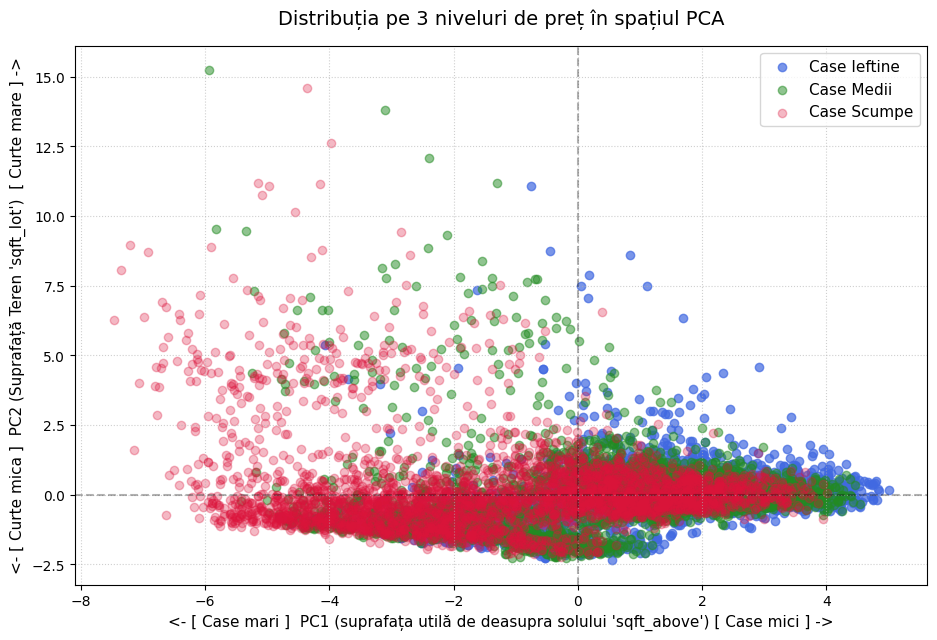

In [8]:


# Calculează pragurile pentru a împărți datele în 3 părți egale
prag_ieftin = np.percentile(data_clean['price'], 33.33)
prag_scump = np.percentile(data_clean['price'], 66.66)

# Creaza categorii de preț categorie
este_ieftina = data_clean['price'] <= prag_ieftin
este_scumpa = data_clean['price'] > prag_scump
este_medie = (data_clean['price'] > prag_ieftin) & (data_clean['price'] <= prag_scump)

# Defineste graficul 2D simplu
plt.figure(figsize=(11, 7))

# Albastru = Case Ieftine
plt.scatter(
    df_rezultat.iloc[este_ieftina, 0], # coloana 0 PC1
    df_rezultat.iloc[este_ieftina, 1], # coloana 1 PC2
    color='royalblue', alpha=0.7, label='Case Ieftine')

# Verde = Case Medii
plt.scatter(
    df_rezultat.iloc[este_medie, 0], 
    df_rezultat.iloc[este_medie, 1], 
    color='forestgreen', alpha=0.5, label='Case Medii')

# Roșu = Case Scumpe
plt.scatter(
    df_rezultat.iloc[este_scumpa, 0], 
    df_rezultat.iloc[este_scumpa, 1], 
    color='crimson', alpha=0.3, label='Case Scumpe')


plt.title("Distribuția pe 3 niveluri de preț în spațiul PCA", fontsize=14, pad=15)
plt.xlabel("<- [ Case mari ]  PC1 (suprafața utilă de deasupra solului 'sqft_above') [ Case mici ] ->", fontsize=11)
plt.ylabel("<- [ Curte mica ]  PC2 (Suprafață Teren 'sqft_lot')  [ Curte mare ] ->", fontsize=11)

# Liniile negre de ghidaj din centru (axele 0,0)
plt.axvline(0, color='black', linestyle='--', alpha=0.3)
plt.axhline(0, color='black', linestyle='--', alpha=0.3)

plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11)
plt.show()
